# 0. Environment Setup

In [1]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata2 as unicodedata 
import re
from dotenv import load_dotenv
import os

import sys
sys.path.insert(0, "..")

from src.config import (RAW_DATA_DIR, ROOT_DIR, PROCESSED_DATA_DIR)
from src.data_preparation import (explore_data, normalize_text)

# Show all columns 
pd.set_option('display.max_columns', None)

# Bold Text Setup
b_start = '\033[1m'
b_end = '\033[0m'

# Graph visual style
sns.set_theme(style="whitegrid")

print('Environment Ready')

Environment Ready


-----
# 1. Exploratory Analysis

In [2]:
# Dataset Load
# URL direct load discarded since complaint narratives were officially deprecated since Sep. 2026 
# URL_CFPB = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

print('Dataframe Loading...')

load_columns = [
    'Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
    'Consumer complaint narrative', 'Company', 'State', 'ZIP code', 
    'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer',
    'Timely response?', 'Complaint ID']

data = pd.read_csv(f'{RAW_DATA_DIR}\consumer_complaints.csv', low_memory=False, usecols=load_columns)

data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_').str.replace('?', '')

print('Dataframe Correctly Loaded')
print()

explore_features = ['complaint_id']
unique_features = ['product', 'sub_product', 'submitted_via', 'tags', 'company_response_to_consumer']

# Data Exploration
explore_data(data, explore_features, unique_features)

Dataframe Loading...
Dataframe Correctly Loaded

=== DataFrame General Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2396033 entries, 0 to 2396032
Data columns (total 15 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   date_received                 object
 1   product                       object
 2   sub_product                   object
 3   issue                         object
 4   sub_issue                     object
 5   consumer_complaint_narrative  object
 6   company                       object
 7   state                         object
 8   zip_code                      object
 9   tags                          object
 10  submitted_via                 object
 11  date_sent_to_company          object
 12  company_response_to_consumer  object
 13  timely_response               object
 14  complaint_id                  int64 
dtypes: int64(1), object(14)
memory usage: 274.2+ MB


None


=== DataFrame Sample ===


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id
1948780,2015-03-19,Debt collection,Credit card,Cont'd attempts collect debt not owed,Debt was paid,I paid the debt in full in XX/XX/2008 and rece...,"WINN LAW GROUP, APC",CA,91775,NaN,Web,2015-03-25,Closed with explanation,Yes,1291211
2054887,2016-04-25,Mortgage,Conventional fixed mortgage,"Loan modification,collection,foreclosure",NaN,By failing to adhere to both California law an...,Specialized Loan Servicing Holdings LLC,CA,92101,NaN,Web,2016-04-25,Closed with explanation,Yes,1894747
2200986,2018-09-11,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,NaN,"I.Q. DATA INTERNATIONAL, INC.",CA,91306,NaN,Web,2018-09-11,Closed with explanation,Yes,3015871



=== Fields with missing values ===


...

array(['Email', 'Fax', 'Phone', 'Postal mail', 'Referral', 'Web'],
      dtype=object)


=== Unique values for tags ===


array(['Older American', 'Older American, Servicemember', 'Servicemember',
       nan], dtype=object)


=== Unique values for company_response_to_consumer ===


array(['Closed', 'Closed with explanation', 'Closed with monetary relief',
       'Closed with non-monetary relief', 'Closed with relief',
       'Closed without relief', 'In progress', 'Untimely response', nan],
      dtype=object)

In [4]:
# Null Values drop
dropna_fields = ['consumer_complaint_narrative', 'issue', 'state']
data.dropna(subset=dropna_fields, how='any', inplace=True)

# Data Type correction and enrichment
date_fields = ['date_received', 'date_sent_to_company']

for field in date_fields:
    data[field] = pd.to_datetime(data[field], format='%Y-%m-%d')

data['month_received'] = data['date_received'].dt.to_period('M')
data['month_received'] = data['month_received'].dt.to_timestamp()

# Dataframe filtering based on specific dates
time_span_years = 5
start_year = data['date_received'].dt.year.max() - time_span_years + 1
df = data[(data['date_received'].dt.year >= start_year) & (data['month_received'] < '2021-11-01')]

# Dataframe filtering based on specific products
focus_products = [
    'Bank account or service', 'Checking or savings account', 'Credit card', 
    'Credit card or prepaid card', 'Money transfer, virtual currency, or money service',
    'Money transfers','Virtual currency']

df = df[df['product'].isin(focus_products)]

# Text Normalization
df['company'] = df['company'].apply(normalize_text)
df['consumer_complaint_narrative'] = df['consumer_complaint_narrative'].apply(normalize_text).str.lower()

# Changes check
print(f'{b_start}DataFrame General Info{b_end}')
display(df.info())
print()
print(f'{b_start}DataFrame Sample{b_end}')
display(df.sample(3))
print()

DataFrame General Info
<class 'pandas.core.frame.DataFrame'>
Index: 124546 entries, 15 to 2395806
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date_received                 124546 non-null  datetime64[ns]
 1   product                       124546 non-null  object        
 2   sub_product                   121397 non-null  object        
 3   issue                         124546 non-null  object        
 4   sub_issue                     99787 non-null   object        
 5   consumer_complaint_narrative  124546 non-null  object        
 6   company                       124546 non-null  object        
 7   state                         124546 non-null  object        
 8   zip_code                      124375 non-null  object        
 9   tags                          23571 non-null   object        
 10  submitted_via                 124546 non-null  object       

None


DataFrame Sample


,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company,state,zip_code,tags,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,complaint_id,month_received
15,2019-06-05,Credit card or prepaid card,General-purpose credit card or charge card,Fees or interest,Problem with fees,i have a bank of america small business credit...,BANK OF AMERICA NATIONAL ASSOCIATION,CA,92618,NaN,Web,2019-06-05,Closed with monetary relief,Yes,3265029,2019-06-01
125936,2020-07-27,Credit card or prepaid card,Store credit card,Incorrect information on your report,Account information incorrect,have been trying to resolve this issue with co...,ALLIANCE DATA CARD SERVICES,TX,77316,Servicemember,Web,2020-07-27,Closed with explanation,Yes,3764862,2020-07-01
753810,2017-10-27,Checking or savings account,Checking account,Unable to get your credit report or credit score,Other problem getting your report or credit score,i am years old and have a combination of perso...,CAPITAL ONE FINANCIAL CORPORATION,NV,89511,NaN,Web,2017-10-27,Closed with explanation,Yes,2714381,2017-10-01


# 2. Descriptive and Statistical Analysis

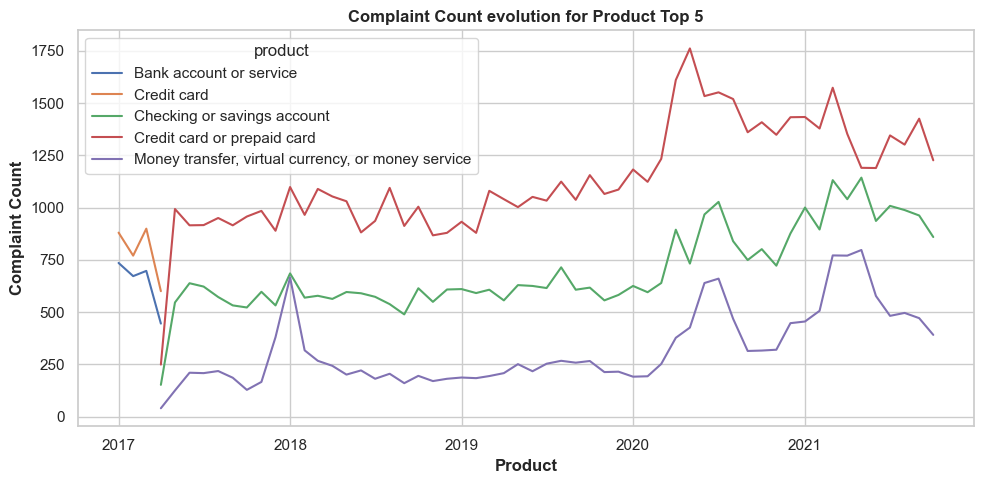

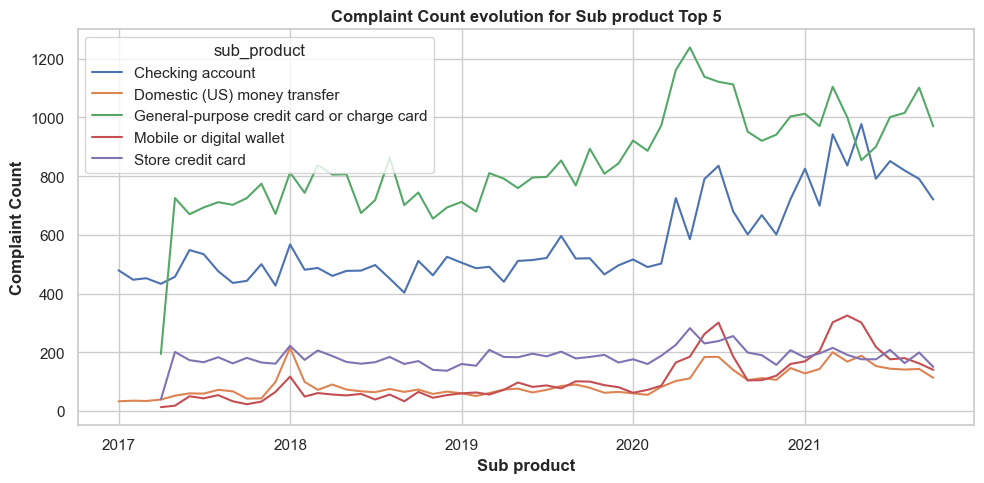

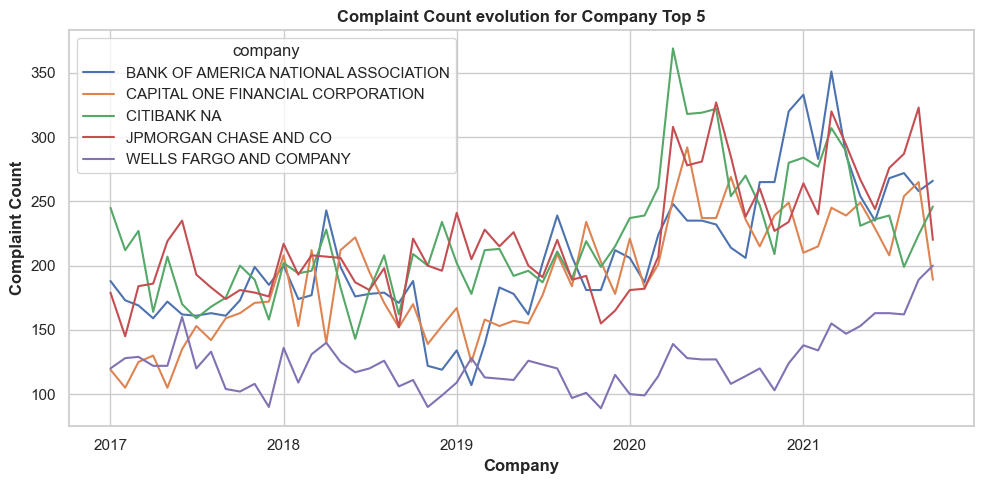

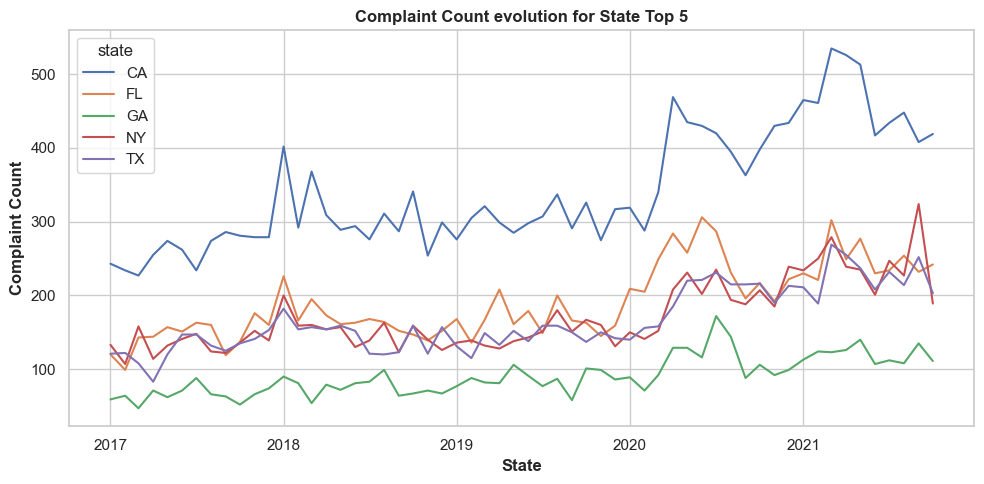

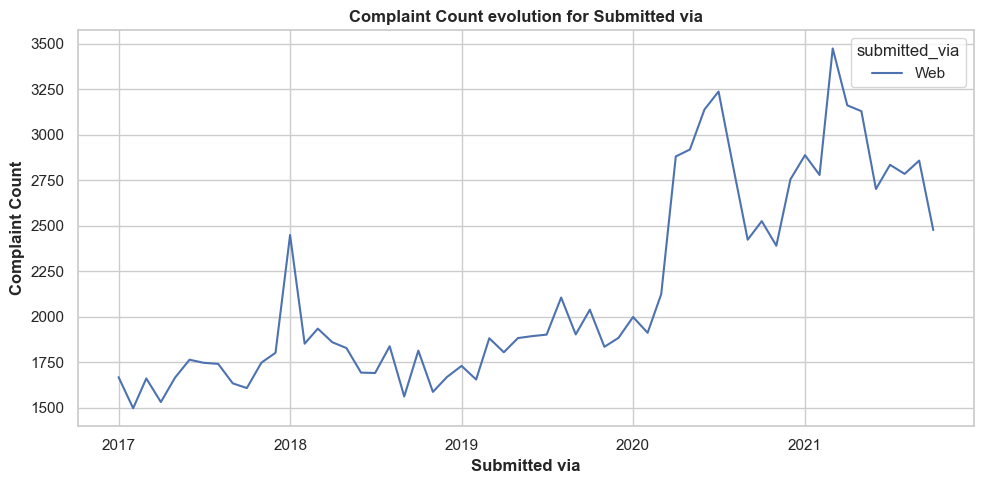

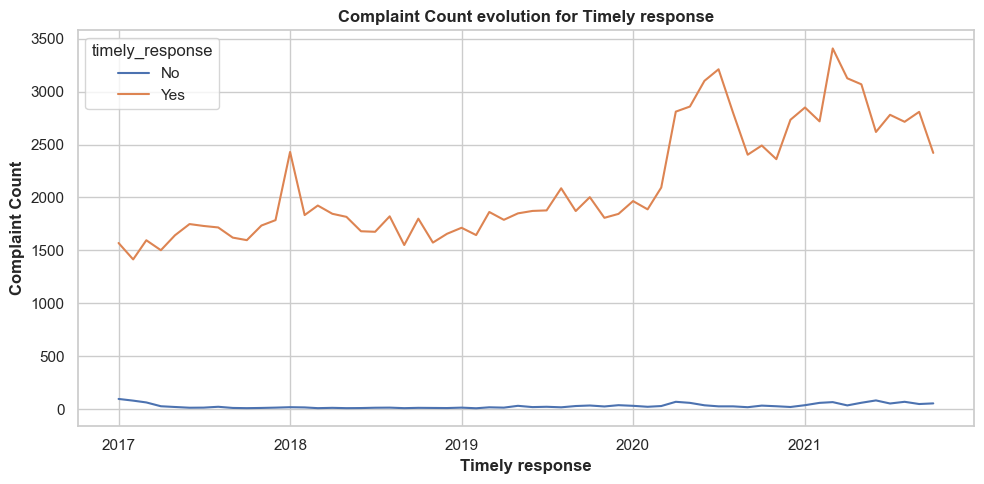

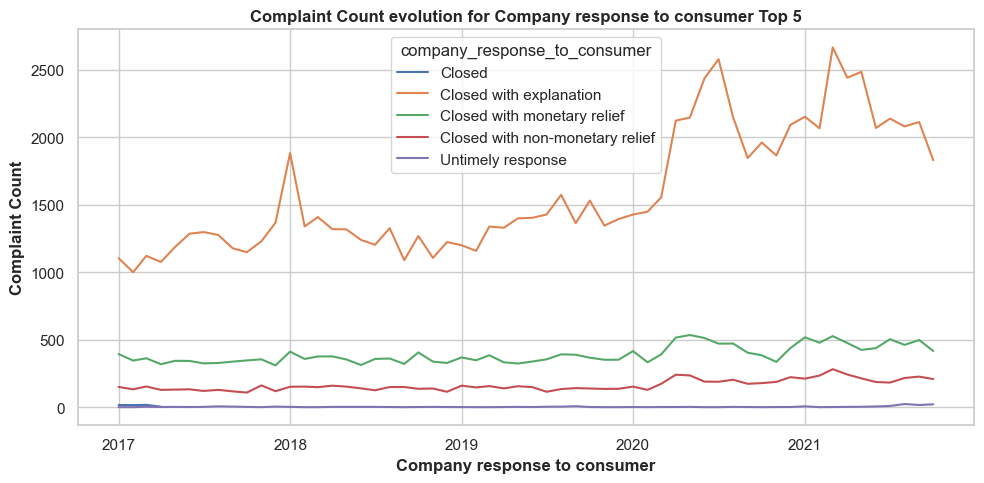

In [5]:
# Complaint Evolution
visualize_features = ['product', 'sub_product', 'company', 'state', 'submitted_via', 'timely_response', 'company_response_to_consumer']

for feature in visualize_features:
    N_features = 5
    
    grouped = df.groupby(['month_received', feature], as_index=False)['complaint_id'].nunique()
    grouped.rename(columns={'complaint_id':'complaint_count'}, inplace=True)

    if grouped[feature].nunique() < N_features:
        N_features = grouped[feature].nunique()
    
    top_features = grouped.groupby(feature, as_index=False)['complaint_count'].sum()
    top_features = top_features.sort_values(by=['complaint_count'], ascending=False)[feature].head(N_features)
    
    grouped = grouped[grouped[feature].isin(top_features)]

    plt.figure(figsize=(10,5))
    sns.lineplot(data=grouped,
                x='month_received',
                y='complaint_count',
                hue=feature
               )
    if N_features > 4:
        plt.title(f'Complaint Count evolution for {feature.replace('_', ' ').capitalize()} Top {N_features}', fontweight='bold')
    else:
        plt.title(f'Complaint Count evolution for {feature.replace('_', ' ').capitalize()}', fontweight='bold')
    plt.xlabel(f'{feature.replace('_', ' ').capitalize()}', fontweight='bold')
    plt.ylabel('Complaint Count', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

In [6]:
# Cleaned Dataframe Export
file_name = 'cleaned_complaints.csv'
df.to_csv(f'{PROCESSED_DATA_DIR}\{file_name}', index=False, sep=';')
print(f'Dataframe {file_name} exported to folder {PROCESSED_DATA_DIR}')

Dataframe cleaned_complaints.csv exported to folder C:\Users\ASUS\OneDrive\Desktop\Proyectos\Consumer-Complaints-Fraud-Correlation-Analysis\notebooks\..\data\processed_data
